C:\Users\adria\AppData\Local\Temp\ipykernel_10892\1592164682.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)


✓ Successfully loaded pre-calculated 'age' column from CSV.
✓ Data Loaded: 516,188 US vehicle transactions
✓ Removed 0 non-US transactions

MAIN QUESTION 1: DESCRIPTIVE STATISTICS & BASELINE DISTRIBUTIONS

--- 1.1 CONTINUOUS VARIABLES METRICS ---

Target Variable: [SELLINGPRICE]
  - Mean: 12,916.81
  - Median: 12,100.00
  - Mode: 11,000.00
  - StdDev: 7,550.28
  - Skewness: 0.52
  - Min: 500.00
  - Max: 35000.00

Target Variable: [YEAR]
  - Mean: 2010.21
  - Median: 2012.00
  - Mode: 2012.00
  - StdDev: 3.64
  - Skewness: -1.00
  - Min: 1998.00
  - Max: 2015.00

Target Variable: [AGE]
  - Mean: 4.70
  - Median: 3.00
  - Mode: 3.00
  - StdDev: 3.62
  - Skewness: 1.00
  - Min: -1.00
  - Max: 17.00

--- 1.2 CATEGORICAL VALUE FREQUENCIES ---

Top 5 Most Frequent [BODY]:
  - SEDAN: 44.93% of volume
  - SUV: 25.96% of volume
  - HATCHBACK: 4.97% of volume
  - MINIVAN: 4.77% of volume
  - COUPE: 3.06% of volume

Top 5 Most Frequent [STATE]:
  - FL: 15.09% of volume
  - CA: 13.04% of volume
  

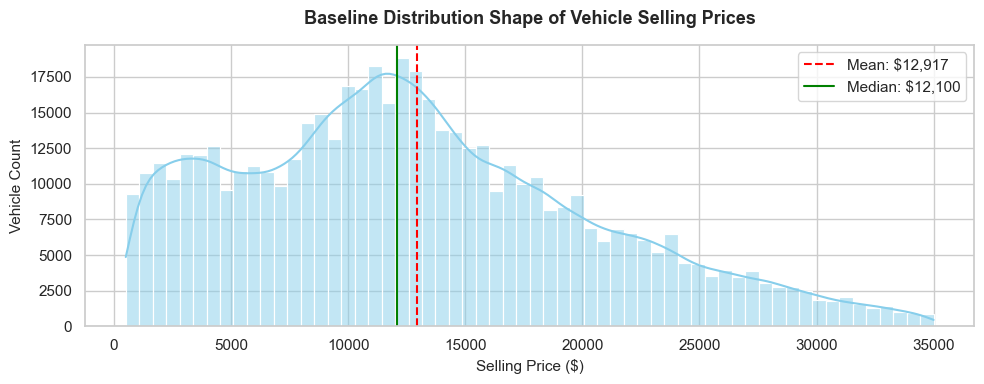

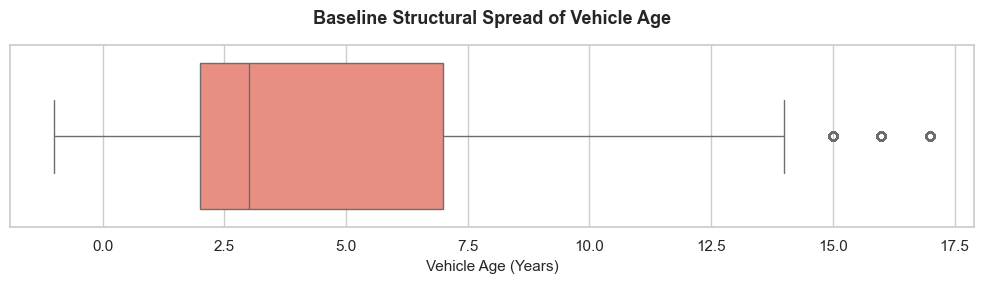

C:\Users\adria\AppData\Local\Temp\ipykernel_10892\1592164682.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bodies.index.str.upper(), y=top_bodies.values, palette='Blues_r')


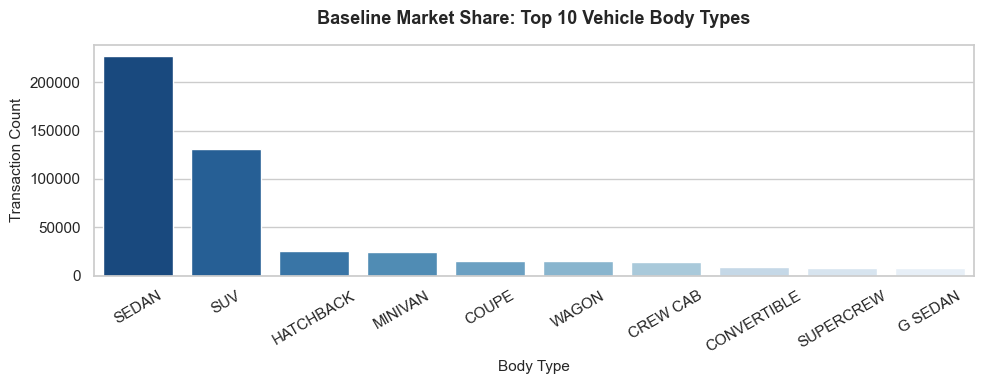

C:\Users\adria\AppData\Local\Temp\ipykernel_10892\1592164682.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_us, x='salemonth', order=existing_months, palette='viridis')


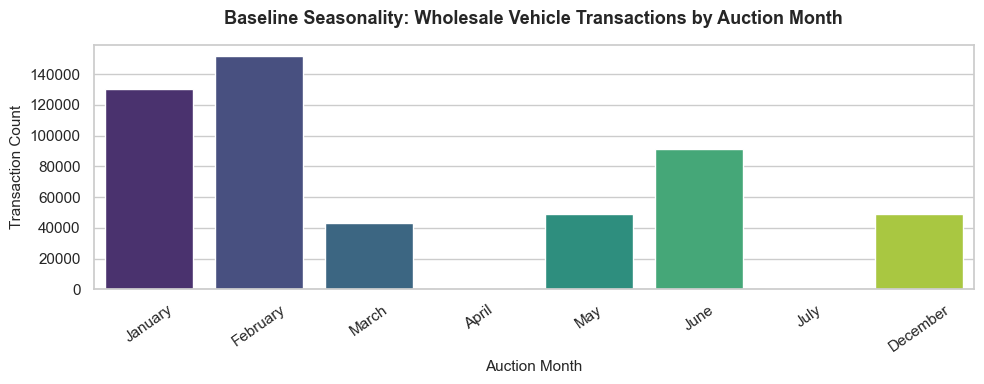


MAIN QUESTION 5: CORRELATION AND PREDICTIVE ANALYSIS

--- 5.1 STATISTICAL CORRELATION MATRIX ---
              sellingprice
age                -0.6302
odometer           -0.6455
condition           0.3351
mmr                 0.9773
sellingprice        1.0000


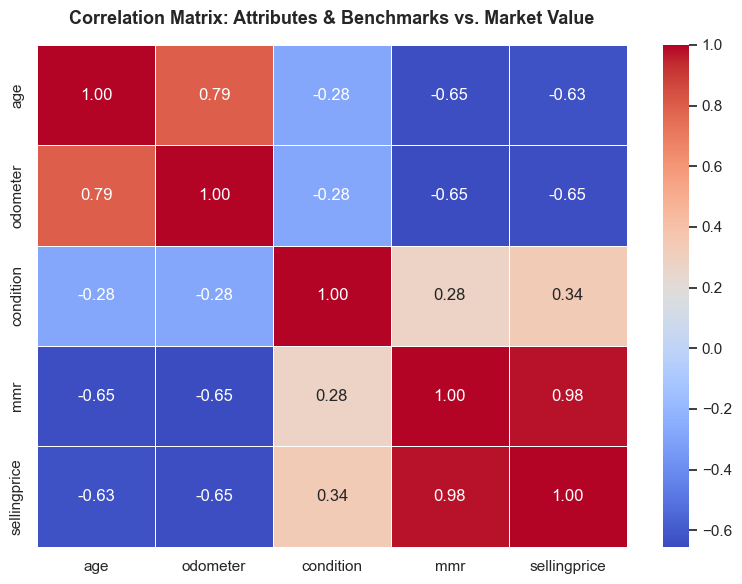


--- 5.2 PREDICTIVE MODEL EVALUATION METRICS ---
  - Mean Absolute Error (MAE): $1011.77
  - Root Mean Squared Error (RMSE): $1515.08
  - Variance Accuracy Score (R²): 0.9596

--- 5.3 MACHINE LEARNING MODEL COEFFICIENTS ---
Predictor Feature  Mathematical Coefficient Weight
              age                        50.735667
         odometer                        -0.002448
        condition                        38.451769
              mmr                         0.976531
Model Intercept Constant Baseline: $-1111.82



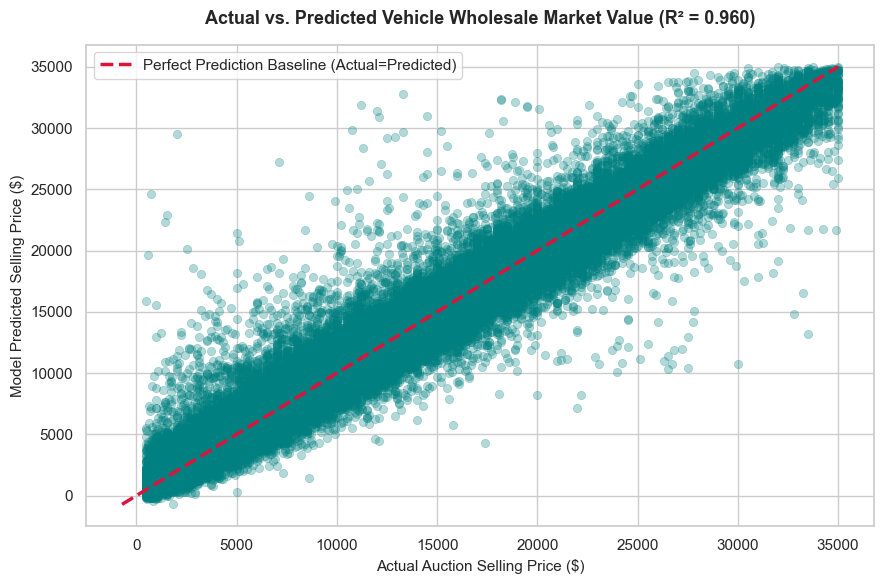

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Ensure charts render inline inside the notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# =========================================================================
# DATA LOADING & CLEANING
# =========================================================================
# Load dataset
df = pd.read_csv("car_sales_cleaned.csv", encoding='ISO-8859-1', sep=None, engine='python')
df.columns = df.columns.str.strip()

# Standardize column names to lowercase to prevent case-sensitive KeyErrors
df.columns = df.columns.str.lower()

# Extract Month and Year from saledate
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce', utc=True)
df['salemonth'] = df['saledate'].dt.strftime('%B') 
df['saleyear'] = df['saledate'].dt.year

# Check if 'age' column exists (since it was manually included in the CSV)
if 'age' not in df.columns:
    print("⚠ 'age' column not found in CSV. Falling back to dynamic calculation...")
    df['age'] = 2026 - df['year']
else:
    print("✓ Successfully loaded pre-calculated 'age' column from CSV.")

# Filter to domestic US states only
us_states = [
    'al', 'az', 'ca', 'co', 'fl', 'ga', 'hi', 'il', 'in', 'la', 'ma', 'md', 
    'mi', 'mn', 'mo', 'ms', 'nc', 'ne', 'nj', 'nm', 'nv', 'ny', 'oh', 'ok', 
    'or', 'pa', 'sc', 'tn', 'tx', 'ut', 'va', 'wa', 'wi'
]
df_us = df[df['state'].str.lower().str.strip().isin(us_states)].copy()

print(f"✓ Data Loaded: {len(df_us):,} US vehicle transactions")
print(f"✓ Removed {len(df) - len(df_us):,} non-US transactions\n")


# =========================================================================
# MAIN QUESTION 1: DESCRIPTIVE STATISTICS (BASELINE DISTRIBUTIONS)
# =========================================================================
print("=" * 70)
print("MAIN QUESTION 1: DESCRIPTIVE STATISTICS & BASELINE DISTRIBUTIONS")
print("=" * 70)

# --- 1.1 Numerical Summaries: Central Tendency, Spread, & Shape ---
print("\n--- 1.1 CONTINUOUS VARIABLES METRICS ---")
metrics = {}
for col in ['sellingprice', 'year', 'age']:
    if col in df_us.columns:
        metrics[col] = {
            'Mean': df_us[col].mean(),
            'Median': df_us[col].median(),
            'Mode': df_us[col].mode().iloc[0] if not df_us[col].mode().empty else np.nan,
            'StdDev': df_us[col].std(),
            'Skewness': df_us[col].skew(),
            'Min': df_us[col].min(),
            'Max': df_us[col].max()
        }

# Print metrics cleanly
for var, stats in metrics.items():
    print(f"\nTarget Variable: [{var.upper()}]")
    for stat_name, stat_val in stats.items():
        fmt = ",.2f" if stat_name in ['Mean', 'Median', 'Mode', 'StdDev'] and var == 'sellingprice' else ".2f"
        print(f"  - {stat_name}: {stat_val:{fmt}}")

# --- 1.2 Categorical Distribution Summaries ---
print("\n--- 1.2 CATEGORICAL VALUE FREQUENCIES ---")
for col in ['body', 'state', 'salemonth']:
    if col in df_us.columns:
        print(f"\nTop 5 Most Frequent [{col.upper()}]:")
        top_cats = df_us[col].astype(str).str.upper().str.strip().value_counts(normalize=True).head(5) * 100
        for cat, pct in top_cats.items():
            print(f"  - {cat}: {pct:.2f}% of volume")

# --- 1.3 Plots: Distributions & Shapes ---

# Plot A: Selling Price Distribution Shape
plt.figure(figsize=(10, 4))
sns.histplot(df_us['sellingprice'], bins=60, kde=True, color='skyblue')
plt.axvline(df_us['sellingprice'].mean(), color='red', linestyle='--', label=f"Mean: ${df_us['sellingprice'].mean():,.0f}")
plt.axvline(df_us['sellingprice'].median(), color='green', linestyle='-', label=f"Median: ${df_us['sellingprice'].median():,.0f}")
plt.title('Baseline Distribution Shape of Vehicle Selling Prices', fontsize=13, weight='bold', pad=15)
plt.xlabel('Selling Price ($)', fontsize=11)
plt.ylabel('Vehicle Count', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# Plot B: Vehicle Age Spread
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_us['age'], color='salmon')
plt.title('Baseline Structural Spread of Vehicle Age', fontsize=13, weight='bold', pad=15)
plt.xlabel('Vehicle Age (Years)', fontsize=11)
plt.tight_layout()
plt.show()

# Plot C: Market Share by Top 10 Vehicle Body Types
if 'body' in df_us.columns:
    plt.figure(figsize=(10, 4))
    top_bodies = df_us['body'].astype(str).str.lower().str.strip().value_counts().head(10)
    sns.barplot(x=top_bodies.index.str.upper(), y=top_bodies.values, palette='Blues_r')
    plt.title('Baseline Market Share: Top 10 Vehicle Body Types', fontsize=13, weight='bold', pad=15)
    plt.xlabel('Body Type', fontsize=11)
    plt.ylabel('Transaction Count', fontsize=11)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Plot D: Seasonality Timing vs Volume
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
existing_months = [m for m in month_order if m in df_us['salemonth'].unique()]

plt.figure(figsize=(10, 4))
sns.countplot(data=df_us, x='salemonth', order=existing_months, palette='viridis')
plt.title('Baseline Seasonality: Wholesale Vehicle Transactions by Auction Month', fontsize=13, weight='bold', pad=15)
plt.xlabel('Auction Month', fontsize=11)
plt.ylabel('Transaction Count', fontsize=11)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


# =========================================================================
# MAIN QUESTION 5: CORRELATION AND PREDICTIVE ANALYSIS
# =========================================================================
print("\n" + "=" * 70)
print("MAIN QUESTION 5: CORRELATION AND PREDICTIVE ANALYSIS")
print("=" * 70)

# Isolate clean analytical columns 
analysis_cols = ['age', 'odometer', 'condition', 'mmr', 'sellingprice']
df_clean = df_us[analysis_cols].dropna()

# --- 5.1 Statistical Correlation Analysis ---
corr_matrix = df_clean.corr()
print("\n--- 5.1 STATISTICAL CORRELATION MATRIX ---")
print(corr_matrix[['sellingprice']].round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Attributes & Benchmarks vs. Market Value', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# --- 5.2 Predictive Analysis (Multiple Linear Regression Model) ---
X = df_clean[['age', 'odometer', 'condition', 'mmr']]
y = df_clean['sellingprice']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and fit the machine learning model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions against holdout testing evaluation sets
y_pred = model.predict(X_test)

# Calculate key predictive accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- 5.2 PREDICTIVE MODEL EVALUATION METRICS ---")
print(f"  - Mean Absolute Error (MAE): ${mae:.2f}")
print(f"  - Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"  - Variance Accuracy Score (R²): {r2:.4f}")

print("\n--- 5.3 MACHINE LEARNING MODEL COEFFICIENTS ---")
coefficients = pd.DataFrame({'Predictor Feature': X.columns, 'Mathematical Coefficient Weight': model.coef_})
print(coefficients.to_string(index=False))
print(f"Model Intercept Constant Baseline: ${model.intercept_:.2f}\n")

# --- 5.4 Visualizing Prediction Error Metrics ---
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='teal', edgecolor=None)

# 1:1 Reference Line for tracking accuracy visual balance
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', lw=2.5, label='Perfect Prediction Baseline (Actual=Predicted)')

plt.xlabel('Actual Auction Selling Price ($)', fontsize=11)
plt.ylabel('Model Predicted Selling Price ($)', fontsize=11)
plt.title(f'Actual vs. Predicted Vehicle Wholesale Market Value (R² = {r2:.3f})', fontsize=13, weight='bold', pad=15)
plt.legend()
plt.tight_layout()
plt.show()
